In [1]:
from diffusers import DDIMScheduler
import torch
import os
import lpips
from PIL import Image
import torchvision.transforms as T
from glob import glob
import pandas as pd
from pathlib import Path
import sys


project_root = Path().resolve().parent
sys.path.append(str(project_root))

from material_aware_flare.eval import calculate_metrics

In [2]:
import sys
sys.path.append("../external/rgbx") 

from rgb2x.load_image import load_exr_image, load_ldr_image
from rgb2x.pipeline_rgb2x import StableDiffusionAOVMatEstPipeline

In [3]:
device = 'cuda'

pipe = StableDiffusionAOVMatEstPipeline.from_pretrained(
    "zheng95z/rgb-to-x",
    torch_dtype=torch.float16,
    cache_dir=os.path.join('./', "model_cache_rgb_x"),
).to(device)
pipe.scheduler = DDIMScheduler.from_config(
    pipe.scheduler.config, rescale_betas_zero_snr=True, timestep_spacing="trailing"
)
pipe.to(device)

/home/hleonhard/miniconda3/envs/rgbx/lib/python3.9/site-packages/huggingface_hub/file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

StableDiffusionAOVMatEstPipeline {
  "_class_name": "StableDiffusionAOVMatEstPipeline",
  "_diffusers_version": "0.20.0",
  "_name_or_path": "zheng95z/rgb-to-x",
  "scheduler": [
    "diffusers",
    "DDIMScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

In [4]:
def rgbx_pipeline(
    pipe,
    filename,
    num_inference_steps,
    seed,
    required_aovs=["albedo", "normal", "roughness", "irradiance"]
):
  generator = torch.Generator(device=device).manual_seed(seed)
  photo = load_ldr_image(filename, from_srgb=True).to(device)
  prompts = {
      "albedo": "Albedo (diffuse basecolor)",
      "normal": "Camera-space Normal",
      "roughness": "Roughness",
      "irradiance": "Irradiance (diffuse lighting)",
  }
  gen_rgbx = []
  for aov_name in required_aovs:
    generated_image = pipe(
        prompt=prompts[aov_name],
        photo=photo,
        num_inference_steps=num_inference_steps,
        height=521,
        width=521,
        generator=generator,
        required_aovs=[aov_name],
    ).images[0][0]
    generated_image = (generated_image, f"Generated {aov_name}")
    gen_rgbx.append(generated_image)
  return gen_rgbx

### Test on single image

In [10]:
test_img_path = "/home/hleonhard/data/flare_subject_data/001/MVI_1814/image/660.png"
lpips_model = lpips.LPIPS(net='vgg').to('cuda')
all_metrics_data = {'albedo': [], 'normal': []}

eval_transform_lpips = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

res = rgbx_pipeline(
    pipe,
    test_img_path,
    20,
    42,
    ["albedo", "normal", "roughness", "metallic", "irradiance"]
)

Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/home/hleonhard/miniconda3/envs/rgbx/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/hleonhard/miniconda3/envs/rgbx/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /home/hleonhard/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:04<00:00, 116MB/s]  


Loading model from: /home/hleonhard/miniconda3/envs/rgbx/lib/python3.9/site-packages/lpips/weights/v0.1/vgg.pth


100%|██████████| 20/20 [00:00<00:00, 20.86it/s]


In [ ]:
import matplotlib.pyplot as plt

flare_albedo = plt.imread('/home/hleonhard/data/flare_models/001/001/images_evaluation/albedo/0660.png')
flare_normal = plt.imread('/home/hleonhard/data/flare_models/001/001/images_evaluation/normal/0660.png')
flare_roughness = plt.imread('/home/hleonhard/data/flare_models/001/001/images_evaluation/roughness/0660.png')
flare_irradiance = plt.imread('/home/hleonhard/data/flare_models/001/001/images_evaluation/irradiance/0660.png')
flare_specular_intensity = plt.imread('/home/hleonhard/data/flare_models/001/001/images_evaluation/specular_intensity/0660.png')

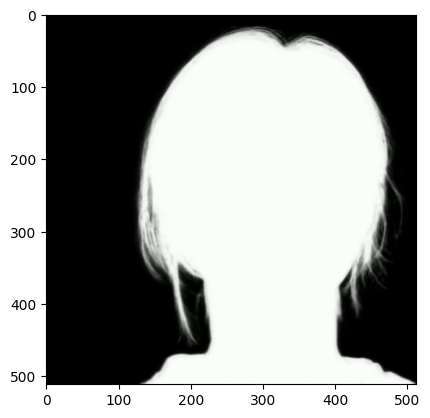

In [20]:
mask = plt.imread('/home/hleonhard/data/flare_subject_data/001/MVI_1814/mask/660.png')
plt.imshow(mask)

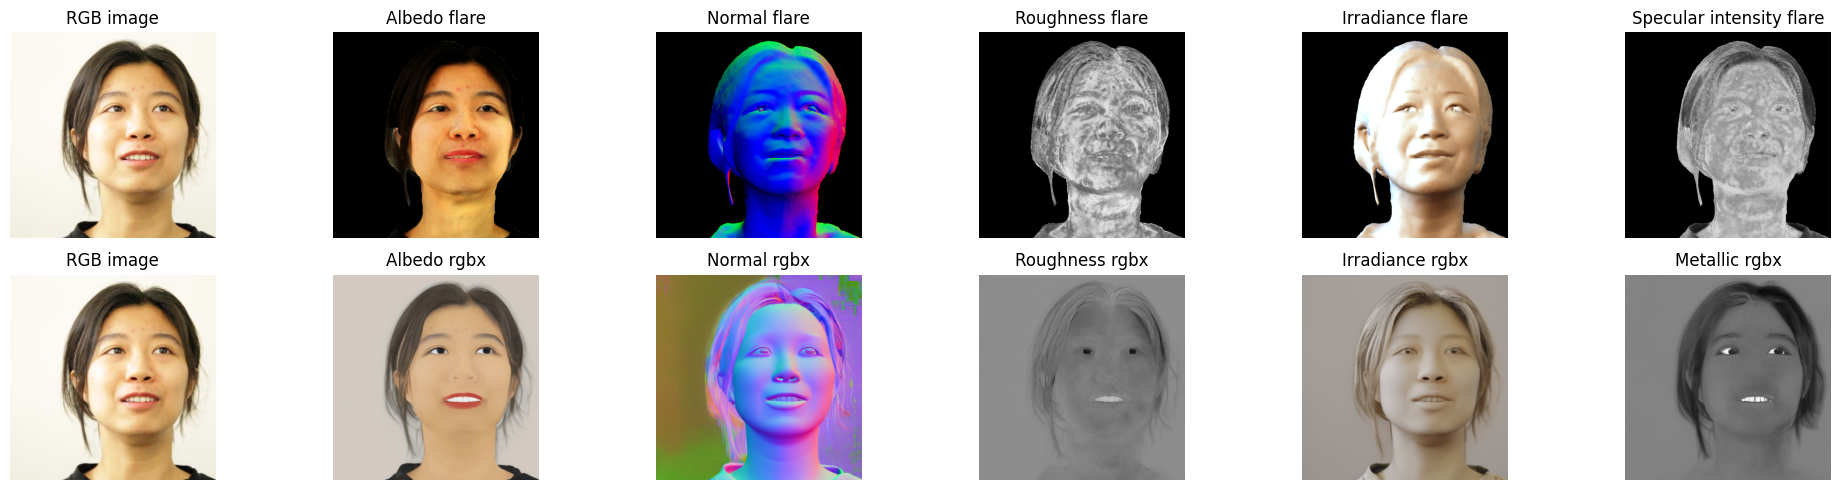

In [16]:
import numpy as np

fig, axs = plt.subplots(2, 6, figsize=(20, 5))
img = plt.imread('/home/hleonhard/data/flare_subject_data/001/MVI_1814/image/660.png')
axs[0,0].imshow(img)
axs[0,0].set_title("RGB image")
axs[0,0].axis('off')
axs[1,0].imshow(img)
axs[1,0].set_title("RGB image")
axs[1,0].axis('off')
axs[0,1].imshow(flare_albedo)
axs[0,1].set_title("Albedo flare")
axs[0,1].axis('off')
axs[1,1].imshow(np.array(res[0][0]))
axs[1,1].set_title("Albedo rgbx")
axs[1,1].axis('off')
axs[0,2].imshow(flare_normal)
axs[0,2].set_title("Normal flare")
axs[0,2].axis('off')
axs[1,2].imshow(np.array(res[1][0]))
axs[1,2].set_title("Normal rgbx")
axs[1,2].axis('off')
axs[0,3].imshow(flare_roughness)
axs[0,3].set_title("Roughness flare")
axs[0,3].axis('off')
axs[1,3].imshow(np.array(res[2][0]))
axs[1,3].set_title("Roughness rgbx")
axs[1,3].axis('off')
axs[0,4].imshow(flare_irradiance)
axs[0,4].set_title("Irradiance flare")
axs[0,4].axis('off')
axs[1,4].imshow(np.array(res[4][0]))
axs[1,4].set_title("Irradiance rgbx")
axs[1,4].axis('off')
axs[0,5].imshow(flare_specular_intensity)
axs[0,5].set_title("Specular intensity flare")
axs[0,5].axis('off')
axs[1,5].imshow(np.array(res[3][0]))
axs[1,5].set_title("Metallic rgbx")
axs[1,5].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# Note: This is the unmasked implementation
flare_albedo_img = Image.open('/home/hleonhard/data/flare_models/001/001/images_evaluation/albedo/0660.png')

calculate_metrics(
     gen_pil=flare_albedo_img, 
     gt_pil=res[0][0],
     lpips_model=lpips_model, 
     lpips_transform=eval_transform_lpips, 
     device='cuda',
     mask_np=mask
)

(18.319984934993425, 0.6889554801710006, 0.25696200132369995)

In [ ]:
# Note: This is the unmasked implementation (4.903886392852899, 0.25056909633663466, 0.47040802240371704)
flare_albedo_img = Image.open('/home/hleonhard/data/flare_models/001/001/images_evaluation/albedo/0660.png')

calculate_metrics(
     gen_pil=flare_albedo_img, 
     gt_pil=res[0][0],
     lpips_model=lpips_model, 
     lpips_transform=eval_transform_lpips, 
     device='cuda',
)

(4.903886392852899, 0.25056909633663466, 0.47040802240371704)

### Pipeline to batch generate

In [5]:
pipe.set_progress_bar_config(disable=True)

In [11]:
from tqdm.notebook import tqdm
import imageio
import numpy as np
import matplotlib.pyplot as plt 

In [22]:
images = glob('/home/hleonhard/data/flare_subject_data/001/MVI_1814/image/**.png')
out_dir = '/home/hleonhard/data/flare_diffusion_channels/rgbx/001/MVI_1814/'
passes = ["albedo", "normal", "roughness", "irradiance"]
for image_path in tqdm(images, total=len(images)):
    img_id = image_path.split('/')[-1]
    res = rgbx_pipeline(
        pipe,
        image_path,
        20,
        42,
        passes
    )
    imageio.imwrite(f'{out_dir}albedo/{img_id}', np.asarray(res[0][0]))
    imageio.imwrite(f'{out_dir}normal/{img_id}', np.asarray(res[1][0]))
    imageio.imwrite(f'{out_dir}roughness/{img_id}', np.asarray(res[2][0]))
    imageio.imwrite(f'{out_dir}irradiance/{img_id}', np.asarray(res[3][0]))

  0%|          | 0/1713 [00:00<?, ?it/s]

In [9]:
from glob import glob
images = glob('/home/hleonhard/data/flare_subject_data/001/MVI_1812/image/**.png')
masks = glob('/home/hleonhard/data/flare_subject_data/001/MVI_1812/mask/**.png')
marker  = pd.read_csv("diffusionrenderer_001_mvi_1812_subset.csv", index_col=0)
images = [image for image in images if image.split('/')[-1] in marker.iloc[:,0].values]
masks = [mask for mask in masks if mask.split('/')[-1] in marker.iloc[:,0].values]

In [10]:
lpips_model = lpips.LPIPS(net='vgg').to('cuda')
all_metrics_data = {'albedo': [], 'normal': [], 'roughness': [], 'irradiance': []}

eval_transform_lpips = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# images = glob('/home/hleonhard/data/flare_subject_data/001/MVI_1814/image/**.png')
# masks = glob('/home/hleonhard/data/flare_subject_data/001/MVI_1814/mask/**.png')
flare_paths = [
  '/home/hleonhard/data/flare_models/001/MVI_1812/images_evaluation/albedo/',
  '/home/hleonhard/data/flare_models/001/MVI_1812/images_evaluation/normal/',
  '/home/hleonhard/data/flare_models/001/MVI_1812/images_evaluation/roughness/',
  '/home/hleonhard/data/flare_models/001/MVI_1812/images_evaluation/irradiance/'
]  
passes = ["albedo", "normal", "roughness", "irradiance"]

for image_path, mask_path in tqdm(zip(images, masks), total=len(images)):
  img_id = image_path.split('/')[-1]
  assert img_id == mask_path.split('/')[-1], f"Warning: Image does not match mask {image_path} to {mask_path}"
  mask = plt.imread(mask_path)
  res = rgbx_pipeline(
      pipe,
      image_path,
      20,
      42,
      passes
  )
  for i, (pass_name, flare_path) in enumerate(zip(passes, flare_paths)):
    gen_path = flare_path + img_id.zfill(8)
    if Path(gen_path).exists():
      gen_image_pil = Image.open(gen_path)
      psnr_val, ssim_val, lpips_val = calculate_metrics(
          gen_pil=gen_image_pil, 
          gt_pil=res[i][0],
          lpips_model=lpips_model, 
          lpips_transform=eval_transform_lpips, 
          device='cuda',
          mask_np=mask
      )
      metrics_data = {
          'file': img_id,
          'pass': pass_name,
          'psnr': psnr_val,
          'ssim': ssim_val,
          'lpips': lpips_val
      }
      all_metrics_data[pass_name].append(metrics_data)
    else:
      print(f"Warning: {gen_path} does not exist")


Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/home/hleonhard/miniconda3/envs/rgbx/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/hleonhard/miniconda3/envs/rgbx/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/hleonhard/miniconda3/envs/rgbx/lib/python3.9/site-packages/lpips/weights/v0.1/vgg.pth


  0%|          | 0/607 [00:00<?, ?it/s]

In [11]:
print("\n" + "="*30)
print(" FINAL EVALUATION METRICS ON 001/MVI_1812 on first 33 percent of frames")
print("="*30)
# In a single-node script, no 'gather' is needed.
all_metrics_list = all_metrics_data['albedo'] + all_metrics_data['normal']  + all_metrics_data['roughness']  + all_metrics_data['irradiance']
if len(all_metrics_list) == 0:
    print("No metrics gathered.")
else:
    df = pd.DataFrame(all_metrics_list)
    # Calculate and print averages
    for pass_name in passes:
        pass_df = df[df['pass'] == pass_name]
        if pass_df.empty:
            print(f"\nNo metrics calculated for {pass_name}.")
            continue
        avg_psnr = pass_df['psnr'].mean()
        avg_ssim = pass_df['ssim'].mean()
        avg_lpips = pass_df['lpips'].mean()
        print(f"\n--- Average Metrics for: {pass_name} ---")
        print(f"  PSNR:  {avg_psnr:.4f}")
        print(f"  SSIM:  {avg_ssim:.4f}")
        print(f"  LPIPS: {avg_lpips:.4f}")


 FINAL EVALUATION METRICS ON 001/MVI_1812 on first 33 percent of frames

--- Average Metrics for: albedo ---
  PSNR:  18.1671
  SSIM:  0.6581
  LPIPS: 0.2668

--- Average Metrics for: normal ---
  PSNR:  13.7313
  SSIM:  0.5766
  LPIPS: 0.3151

--- Average Metrics for: roughness ---
  PSNR:  19.5378
  SSIM:  0.5440
  LPIPS: 0.3690

--- Average Metrics for: irradiance ---
  PSNR:  15.8312
  SSIM:  0.7091
  LPIPS: 0.3330


In [11]:
print("\n" + "="*30)
print(" FINAL EVALUATION METRICS ON 001")
print("="*30)
# In a single-node script, no 'gather' is needed.
all_metrics_list = all_metrics_data['albedo'] + all_metrics_data['normal']  + all_metrics_data['roughness']  + all_metrics_data['irradiance']
if len(all_metrics_list) == 0:
    print("No metrics gathered.")
else:
    df = pd.DataFrame(all_metrics_list)
    # Calculate and print averages
    for pass_name in passes:
        pass_df = df[df['pass'] == pass_name]
        if pass_df.empty:
            print(f"\nNo metrics calculated for {pass_name}.")
            continue
        avg_psnr = pass_df['psnr'].mean()
        avg_ssim = pass_df['ssim'].mean()
        avg_lpips = pass_df['lpips'].mean()
        print(f"\n--- Average Metrics for: {pass_name} ---")
        print(f"  PSNR:  {avg_psnr:.4f}")
        print(f"  SSIM:  {avg_ssim:.4f}")
        print(f"  LPIPS: {avg_lpips:.4f}")


 FINAL EVALUATION METRICS ON 001

--- Average Metrics for: albedo ---
  PSNR:  18.3829
  SSIM:  0.6662
  LPIPS: 0.2645

--- Average Metrics for: normal ---
  PSNR:  13.7682
  SSIM:  0.5813
  LPIPS: 0.3140

--- Average Metrics for: roughness ---
  PSNR:  18.7877
  SSIM:  0.5436
  LPIPS: 0.3670

--- Average Metrics for: irradiance ---
  PSNR:  16.0082
  SSIM:  0.7135
  LPIPS: 0.3266
